In [1]:
import scanpy as sc
import muon as mu
import topomics as ot
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pandas as pd
from topomics import MultimodalAmortizedLDA
import seaborn as sns
warnings.filterwarnings('ignore', message='.*was not registered in the param store.*')
warnings.filterwarnings('ignore', message='.*Found plate statements in guide but not model.*')

/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# TEA-seq dataset: https://www.omicsdi.org/dataset/geo/GSE158013

mdata = mu.read_h5mu("/data/GSE158013/GSM5123951.h5mu")

/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [3]:
mdata

MuData object with n_obs × n_vars = 5805 × 113187
  obs:	'sample', 'well', 'leiden_multiplex', 'leiden_mofa'
  var:	'highly_variable', 'gene_ids', 'feature_types', 'genome', 'interval'
  uns:	'leiden', 'leiden_mofa', 'leiden_mofa_colors', 'mofa', 'umap'
  obsm:	'X_mofa', 'X_mofa_umap', 'X_umap'
  varm:	'LFs'
  obsp:	'mofa_connectivities', 'mofa_distances'
  3 modalities
    rna:	5805 x 16381
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'hvg', 'leiden', 'leiden_colors', 'leiden_multiplex_colors', 'log1p', 'neighbors', 'pca', 'rna:leiden_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'lognorm'
      obsp:	'connectivities', 'distances'
    atac:	5805 x 96760
      obs:	'n_fragments', 'n_duplicate', 'n_mito', 'n_unique', 'altius_count', 'altius_frac', 'gene_bodies_count', 'gene_bodies_frac', 'peaks_count', 'peaks_frac', 'tss_count', 'tss_frac', 'barcodes', 'cell_name', 'well_id', 'chip_id', 'batch_id', 'pbmc_sample_id', 'DoubletScore', 'DoubletEnrichment', 'TSSEnrichment', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'lognorm'
      obsp:	'connectivities', 'distances'
    prot:	5805 x 46
      obs:	'total_counts'
      var:	'highly_variable'
      uns:	'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

In [4]:
mdata.mod['atac'].layers['counts'] = (mdata.mod['atac'].layers['counts'] > 0).astype(int)

In [5]:
# Filter a bit to have it last a reasonable time
sc.pp.highly_variable_genes(mdata.mod['rna'], n_top_genes=2000, flavor='seurat_v3', layer='counts')
mdata.mod['rna'] = mdata.mod['rna'][:, mdata.mod['rna'].var['highly_variable']].copy()

sc.pp.highly_variable_genes(mdata.mod['atac'], n_top_genes=10000, flavor='seurat_v3', layer='counts')
mdata.mod['atac'] = mdata.mod['atac'][:, mdata.mod['atac'].var['highly_variable']].copy()

model = MultimodalAmortizedLDA.from_data(
    mdata,
    modalities=["rna", "atac", "prot"],  # specify which modalities to use
    n_topics=10,
    likelihoods=["gamma_poisson", "bernoulli", "gamma_poisson"],
    layers='counts',
    n_hidden=64,
    cell_topic_prior=1/10,
    weight_mode = 'cell',
    normalize_encoder_inputs= True
)

In [ ]:
model.train(
    max_epochs=1000,
    batch_size=128,  
    train_size=0.8,          
    validation_size=0.2,      
    log_every_n_steps=1,     
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many

Epoch 678/1000:  68%|██████▊   | 677/1000 [32:44<12:08,  2.25s/it, v_num=1, elbo_val=2.57e+7, elbo_train=1e+8]   

In [ ]:
import scvi
import torch
dl = model._make_data_loader(adata=model.adata, batch_size=128)
batch = next(iter(dl))
x = batch[scvi.REGISTRY_KEYS.X_KEY]
print(torch.isnan(x).any())



tensor(False)


Text(0, 0.5, 'ELBO')

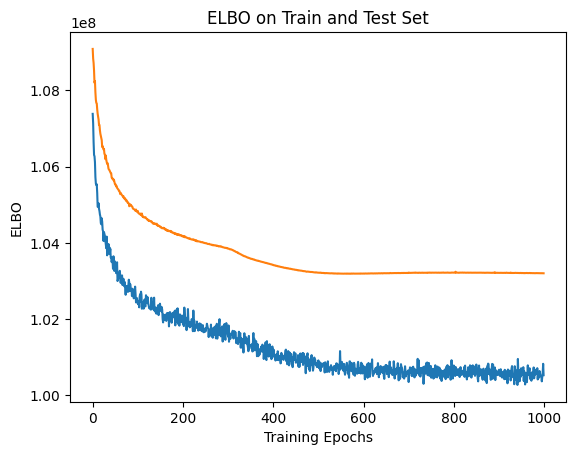

In [ ]:
plt.plot(model.history['elbo_train'])
plt.plot(model.history['elbo_val']*4)
plt.title('ELBO on Train and Test Set')
plt.xlabel('Training Epochs')
plt.ylabel('ELBO')

In [ ]:
#This API is terrible, I really need to change it

adata_concat = mdata.uns["_flattened_ann_data"]

# Get latent representation
theta = model.get_latent_representation(adata_concat, batch_size=mdata.n_obs)

In [ ]:
mdata.obsm["X_topic"] = theta.values - 1/theta.values.shape[1]

sc.pp.neighbors(mdata, use_rep="X_topic", n_neighbors=15, metric="cosine")
sc.tl.umap(mdata, min_dist=0.3)

# 3) Get dominant topic per cell
mdata.obs["dominant_topic"] = theta.idxmax(axis=1).values

# 4) IMPORTANT: Clean up any old color information to avoid conflicts
if "dominant_topic_colors" in mdata.uns:
    del mdata.uns["dominant_topic_colors"]

# 5) Convert to categorical for better plotting
mdata.obs["dominant_topic"] = pd.Categorical(mdata.obs["dominant_topic"])

<Axes: title={'center': 'Topic space colored by Leiden Cluster'}, xlabel='X_topic1', ylabel='X_topic2'>

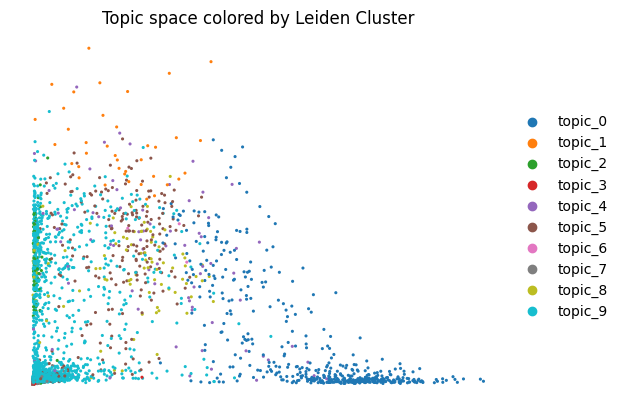

In [ ]:
mu.pl.embedding(
    mdata,
    basis = "X_topic",
    color="dominant_topic",
    frameon=False,
    s=20,
    title="Topic space colored by Leiden Cluster",
    show=False,
    legend_loc="right margin"
)

In [ ]:
print("\n" + "="*70)
print("TOPIC ABUNDANCE SUMMARY")
print("="*70)

summary_df = pd.DataFrame({
    "Mean": theta.mean(),
    "Std": theta.std(),
    "Min": theta.min(),
    "Max": theta.max(),
    "# Dominant Cells": [(theta.idxmax(axis=1) == topic).sum() for topic in theta.columns]
})

print(summary_df.round(3).to_string())


TOPIC ABUNDANCE SUMMARY
          Mean    Std    Min    Max  # Dominant Cells
topic_0  0.055  0.122  0.001  0.664               489
topic_1  0.033  0.060  0.001  0.365                38
topic_2  0.075  0.094  0.001  0.451                77
topic_3  0.044  0.156  0.001  0.871               293
topic_4  0.124  0.092  0.001  0.467               101
topic_5  0.066  0.098  0.001  0.484               216
topic_6  0.049  0.056  0.001  0.408                 7
topic_7  0.161  0.302  0.001  0.926              1201
topic_8  0.086  0.079  0.002  0.393                91
topic_9  0.306  0.246  0.001  0.890              3292


<Axes: title={'center': 'Umap of data colored by Dominant Topic'}, xlabel='X_umap1', ylabel='X_umap2'>

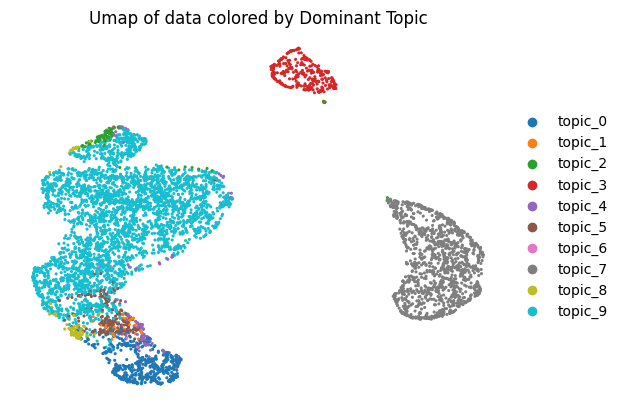

In [ ]:
mu.pl.embedding(
    mdata,
    basis = "X_umap",
    color="dominant_topic",
    frameon=False,
    s=20,
    title="Umap of data colored by Dominant Topic",
    show=False,
    legend_loc="right margin"
)

In [ ]:
perplexity = model.get_perplexity()
print(f"Perplexity: {perplexity:.4f}")

perplexity_per_mod = model.get_perplexity_per_modality()
for mod_name, ppl in perplexity_per_mod.items():
    print(f"  {mod_name}: {ppl:.4f}")

Perplexity: 0.0024
  rna: 26592059663819851306106880.0000
  atac: 63744404917436596030285844594778249955832820466320130530976144719201545358881813154892534310284279256426438582224494250761430156349946920750916263376956898106082802663215358541824.0000
  prot: 882.9051


In [ ]:
likelihood_per_mod = model.get_likelihood_per_modality()
for mod_name, ll in likelihood_per_mod.items():
    print(f"  {mod_name}: {ll:.2f}")

  rna: -142849990.75
  atac: -5606681520.00
  prot: -33211075.00


In [ ]:
entropy = model.get_entropy(normalised=True)
print(f"Mean cell-topic entropy: {entropy:.4f}")
print(f"Max possible entropy (uniform): {np.log(model.n_topics):.4f}")
print(f"Normalized entropy: {entropy / np.log(model.n_topics):.2%}")

Mean cell-topic entropy: 1.2767
Max possible entropy (uniform): 2.3026
Normalized entropy: 55.45%


In [ ]:
diversity_all = model.get_topic_diversity()
print(f"Overall diversity (avg across modalities): {diversity_all:.4f}")

# Per-modality diversity
print("\nPer-modality diversity:")
diversity_rna = model.get_topic_diversity(modality='rna')
diversity_atac = model.get_topic_diversity(modality='atac')
diversity_prot = model.get_topic_diversity(modality='prot')
print(f"  RNA: {diversity_rna:.4f}")
print(f"  ATAC: {diversity_atac:.4f}")
print(f"  Proteins: {diversity_prot:.4f}")

Overall diversity (avg across modalities): 0.5546

Per-modality diversity:
  RNA: 0.7394
  ATAC: 0.2154
  Proteins: 0.7090


In [ ]:
weights = model.get_modality_weights()
print(f"\nWeights shape: {weights.shape}")
print(f"Weight mode: {model.weight_mode}")


print("\nAverage weight per modality:")
for mod_name in weights.columns:
    mean_weight = weights[mod_name].mean()
    std_weight = weights[mod_name].std()
    print(f"  {mod_name}: {mean_weight:.4f} ± {std_weight:.4f}")


Weights shape: (5805, 3)
Weight mode: universal

Average weight per modality:
  rna: 0.3843 ± 0.0000
  atac: 0.4134 ± 0.0000
  prot: 0.2023 ± 0.0000


In [ ]:
print("\n8. CROSS-MODALITY INTERACTION SCORE")
print("-" * 80)
cross_mod_score = model.cross_modality_score(
    mod_a='rna', 
    mod_b='atac', 
    normalise=True, 
    return_df=True
)
print(f"Cross-modality score matrix shape: {cross_mod_score.shape}")
print(f"Mean interaction score: {cross_mod_score.values.mean():.4f}")
print(f"Max interaction score: {cross_mod_score.values.max():.4f}")


8. CROSS-MODALITY INTERACTION SCORE
--------------------------------------------------------------------------------
Cross-modality score matrix shape: (2000, 10000)
Mean interaction score: 0.0544
Max interaction score: 1.0000



GENERATING VISUALIZATIONS

Saved visualization to: topic_model_metrics.png


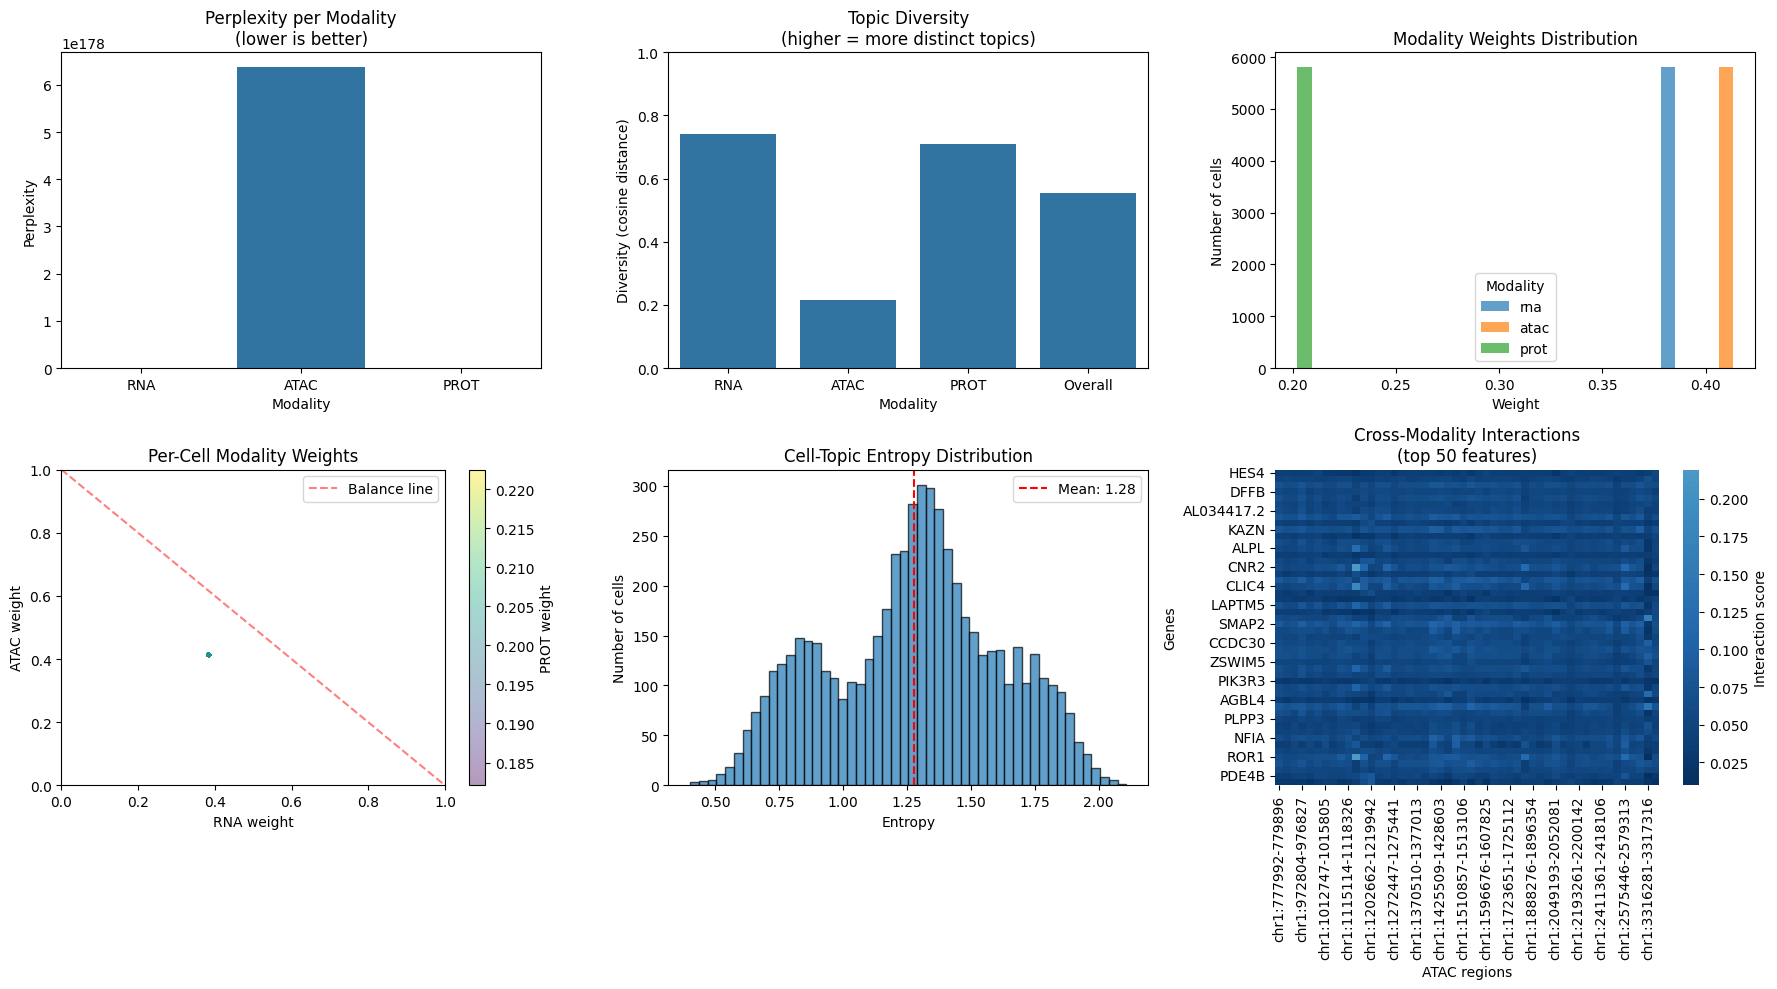


BONUS: TOPIC-SPECIFIC ANALYSIS

Topic assignments (most probable topic per cell):
  Topic 0: 490 cells (8.4%)
  Topic 1: 40 cells (0.7%)
  Topic 2: 80 cells (1.4%)
  Topic 3: 292 cells (5.0%)
  Topic 4: 101 cells (1.7%)
  Topic 5: 213 cells (3.7%)
  Topic 6: 7 cells (0.1%)
  Topic 7: 1201 cells (20.7%)
  Topic 8: 93 cells (1.6%)
  Topic 9: 3288 cells (56.6%)

SUMMARY TABLE
            Metric                                                                                                                                                                                    Value                        Interpretation
Overall Perplexity                                                                                                                                                                                   0.0024         Lower = better reconstruction
    RNA Perplexity                                                                                                                         

In [ ]:
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Perplexity per modality
ax = axes[0, 0]
perp_data = pd.DataFrame({
    'Modality': ['RNA', 'ATAC', 'PROT'],
    'Perplexity': [perplexity_per_mod['rna'],
                   perplexity_per_mod['atac'],
                   perplexity_per_mod['prot']]
})
sns.barplot(data=perp_data, x='Modality', y='Perplexity', ax=ax)
ax.set_title('Perplexity per Modality\n(lower is better)')
ax.set_ylabel('Perplexity')

# 2. Topic diversity comparison
ax = axes[0, 1]
div_data = pd.DataFrame({
    'Modality': ['RNA', 'ATAC', 'PROT', 'Overall'],
    'Diversity': [diversity_rna, diversity_atac, diversity_prot, diversity_all]
})
sns.barplot(data=div_data, x='Modality', y='Diversity', ax=ax)
ax.set_title('Topic Diversity\n(higher = more distinct topics)')
ax.set_ylabel('Diversity (cosine distance)')
ax.set_ylim(0, 1)

# 3. Modality weights distribution
ax = axes[0, 2]
weights[['rna', 'atac', 'prot']].plot.hist(bins=30, alpha=0.7, ax=ax)
ax.set_title('Modality Weights Distribution')
ax.set_xlabel('Weight')
ax.set_ylabel('Number of cells')
ax.legend(title='Modality')

# 4. Modality weights scatter (RNA vs ATAC, colored by PROT weight)
ax = axes[1, 0]
sc = ax.scatter(weights['rna'], weights['atac'],
                c=weights['prot'], cmap='viridis',
                alpha=0.4, s=5)
ax.plot([0, 1], [1, 0], 'r--', alpha=0.5, label='Balance line')
ax.set_xlabel('RNA weight')
ax.set_ylabel('ATAC weight')
ax.set_title('Per-Cell Modality Weights')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
cbar = fig.colorbar(sc, ax=ax, label='PROT weight')

# 5. Cell-topic entropy distribution
ax = axes[1, 1]
theta = model.get_cell_topic_dist()
theta_norm = theta / (theta.sum(axis=1, keepdims=True) + 1e-12)
cell_entropies = -(theta_norm * np.log(np.clip(theta_norm, 1e-8, None))).sum(axis=1)
ax.hist(cell_entropies, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(entropy, color='red', linestyle='--', label=f'Mean: {entropy:.2f}')
ax.set_xlabel('Entropy')
ax.set_ylabel('Number of cells')
ax.set_title('Cell-Topic Entropy Distribution')
ax.legend()

# 6. Cross-modality heatmap (top 50x50 subset for visibility)
ax = axes[1, 2]
subset = cross_mod_score.iloc[:50, :50]
sns.heatmap(subset, cmap='RdBu_r', center=0.5, ax=ax, cbar_kws={'label': 'Interaction score'})
ax.set_title('Cross-Modality Interactions\n(top 50 features)')
ax.set_xlabel('ATAC regions')
ax.set_ylabel('Genes')

plt.tight_layout()
plt.savefig('topic_model_metrics.png', dpi=150, bbox_inches='tight')
print("\nSaved visualization to: topic_model_metrics.png")
plt.show()

# ============================================================================
# BONUS: Topic-specific analysis
# ============================================================================
print("\n" + "=" * 80)
print("BONUS: TOPIC-SPECIFIC ANALYSIS")
print("=" * 80)

# Get cell-topic distributions
theta = model.get_cell_topic_dist()

# Find dominant topic per cell
dominant_topics = theta.argmax(axis=1)
print(f"\nTopic assignments (most probable topic per cell):")
topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
for topic_id, count in topic_counts.items():
    print(f"  Topic {topic_id}: {count} cells ({count/len(theta)*100:.1f}%)")

# ============================================================================
# Summary table
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)

summary = pd.DataFrame({
    'Metric': [
        'Overall Perplexity',
        'RNA Perplexity',
        'ATAC Perplexity',
        'PROT Perplexity',
        'Mean Entropy',
        'RNA Diversity',
        'ATAC Diversity',
        'PROT Diversity',
        'Overall Diversity',
        'Mean RNA Weight',
        'Mean ATAC Weight',
        'Mean PROT Weight',
    ],
    'Value': [
        f"{perplexity:.4f}",
        f"{perplexity_per_mod['rna']:.4f}",
        f"{perplexity_per_mod['atac']:.4f}",
        f"{perplexity_per_mod['prot']:.4f}",
        f"{entropy:.4f}",
        f"{diversity_rna:.4f}",
        f"{diversity_atac:.4f}",
        f"{diversity_prot:.4f}",
        f"{diversity_all:.4f}",
        f"{weights['rna'].mean():.4f}",
        f"{weights['atac'].mean():.4f}",
        f"{weights['prot'].mean():.4f}",
    ],
    'Interpretation': [
        'Lower = better reconstruction',
        'Lower = better RNA reconstruction',
        'Lower = better ATAC reconstruction',
        'Lower = better PROT reconstruction',
        'Higher = more spread topics',
        'Higher = more distinct RNA topics',
        'Higher = more distinct ATAC topics',
        'Higher = more distinct PROT topics',
        'Higher = more distinct topics overall',
        'Higher = model trusts RNA more',
        'Higher = model trusts ATAC more',
        'Higher = model trusts PROT more',
    ]
})

print(summary.to_string(index=False))

print("\n" + "=" * 80)
print("CACHING STATUS")
print("=" * 80)
print(f"Number of cached metrics: {len(model._cached_metrics)}")
print("Cached metric keys:")
for key in model._cached_metrics.keys():
    print(f"  - {key}")
print("\nNote: Subsequent calls to these metrics will use cached values (instant!)")


In [ ]:
model.save('/data/teaseq_gamma_bernoulli_cell_normalized')